In [ ]:
!pip install scipy seaborn


In [3]:
import zipfile
import os

zip_path = "/content/archive (1).zip"  # CHANGE if filename is different
extract_path = "/content/credit_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['sampleEntry.csv', 'Data Dictionary.xls', 'cs-training.csv', 'cs-test.csv']

In [4]:
import pandas as pd
import numpy as np

df_baseline = pd.read_csv("/content/credit_data/cs-training.csv")
df_baseline.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df_baseline = df_baseline.drop(columns=['Unnamed: 0'], errors='ignore')
df_baseline.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [6]:
print("Shape:", df_baseline.shape)
df_baseline.info()
df_baseline.describe()


Shape: (150000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
baseline_profile = {}

for col in df_baseline.columns:
    baseline_profile[col] = {
        "mean": float(df_baseline[col].mean()),
        "std": float(df_baseline[col].std()),
        "min": float(df_baseline[col].min()),
        "max": float(df_baseline[col].max()),
        "missing_pct": float(df_baseline[col].isna().mean())
    }

baseline_profile


{'SeriousDlqin2yrs': {'mean': 0.06684,
  'std': 0.24974553092870277,
  'min': 0.0,
  'max': 1.0,
  'missing_pct': 0.0},
 'RevolvingUtilizationOfUnsecuredLines': {'mean': 6.048438054666888,
  'std': 249.75537062543177,
  'min': 0.0,
  'max': 50708.0,
  'missing_pct': 0.0},
 'age': {'mean': 52.295206666666665,
  'std': 14.77186586310081,
  'min': 0.0,
  'max': 109.0,
  'missing_pct': 0.0},
 'NumberOfTime30-59DaysPastDueNotWorse': {'mean': 0.4210333333333333,
  'std': 4.192781272017265,
  'min': 0.0,
  'max': 98.0,
  'missing_pct': 0.0},
 'DebtRatio': {'mean': 353.00507576386985,
  'std': 2037.8185231443026,
  'min': 0.0,
  'max': 329664.0,
  'missing_pct': 0.0},
 'MonthlyIncome': {'mean': 6670.221237392844,
  'std': 14384.674215282244,
  'min': 0.0,
  'max': 3008750.0,
  'missing_pct': 0.19820666666666667},
 'NumberOfOpenCreditLinesAndLoans': {'mean': 8.45276,
  'std': 5.145950989645247,
  'min': 0.0,
  'max': 58.0,
  'missing_pct': 0.0},
 'NumberOfTimes90DaysLate': {'mean': 0.2659733333

In [8]:
import json

with open("baseline_profile.json", "w") as f:
    json.dump(baseline_profile, f)


In [9]:
df_today = df_baseline.copy()

# Inject missing value spike
for col in df_today.columns[:3]:
    df_today.loc[df_today.sample(frac=0.1).index, col] = np.nan

# Simulate distribution drift
df_today['MonthlyIncome'] = df_today['MonthlyIncome'] * 1.5

# Inject impossible values
df_today.loc[df_today.sample(frac=0.02).index, 'age'] = 150

df_today.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1.0,0.766127,45.0,2,0.802982,13680.0,13,0,6,0,2.0
1,0.0,0.957151,40.0,0,0.121876,3900.0,4,0,0,0,1.0
2,0.0,0.658180,38.0,1,0.085113,4563.0,2,1,0,0,0.0
3,0.0,0.233810,30.0,0,0.036050,4950.0,5,0,0,0,0.0
4,0.0,0.907239,49.0,1,0.024926,95382.0,7,0,1,0,0.0


In [10]:
quality_results = []

for col in df_today.columns:
    today_missing = df_today[col].isna().mean()
    baseline_missing = baseline_profile[col]['missing_pct']

    missing_spike = today_missing - baseline_missing > 0.05

    range_issue = (
        df_today[col].min() < baseline_profile[col]['min'] or
        df_today[col].max() > baseline_profile[col]['max']
    )

    quality_results.append({
        "feature": col,
        "missing_spike": missing_spike,
        "range_issue": range_issue
    })

quality_df = pd.DataFrame(quality_results)
quality_df


,feature,missing_spike,range_issue
0,SeriousDlqin2yrs,True,False
1,RevolvingUtilizationOfUnsecuredLines,True,False
2,age,True,True
3,NumberOfTime30-59DaysPastDueNotWorse,False,False
4,DebtRatio,False,False
5,MonthlyIncome,False,True
6,NumberOfOpenCreditLinesAndLoans,False,False
7,NumberOfTimes90DaysLate,False,False
8,NumberRealEstateLoansOrLines,False,False
9,NumberOfTime60-89DaysPastDueNotWorse,False,False


In [11]:
from scipy.stats import ks_2samp

drift_results = []

for col in df_baseline.columns:
    baseline_values = df_baseline[col].dropna()
    today_values = df_today[col].dropna()

    stat, p_value = ks_2samp(baseline_values, today_values)

    drift_results.append({
        "feature": col,
        "p_value": p_value,
        "drift_detected": p_value < 0.05
    })

drift_df = pd.DataFrame(drift_results)
drift_df.sort_values("p_value")


,feature,p_value,drift_detected
5,MonthlyIncome,0.000000e+00,True
2,age,7.978084e-31,True
1,RevolvingUtilizationOfUnsecuredLines,1.000000e+00,False
0,SeriousDlqin2yrs,1.000000e+00,False
3,NumberOfTime30-59DaysPastDueNotWorse,1.000000e+00,False
4,DebtRatio,1.000000e+00,False
6,NumberOfOpenCreditLinesAndLoans,1.000000e+00,False
7,NumberOfTimes90DaysLate,1.000000e+00,False
8,NumberRealEstateLoansOrLines,1.000000e+00,False
9,NumberOfTime60-89DaysPastDueNotWorse,1.000000e+00,False


In [12]:
score = 100
score -= quality_df['missing_spike'].sum() * 5
score -= quality_df['range_issue'].sum() * 5
score -= drift_df['drift_detected'].sum() * 10
score = max(score, 0)

print(f"Data Reliability Score: {score}/100")


Data Reliability Score: 55/100


In [13]:
if score >= 85:
    print("✅ Data is SAFE for ML/Analytics")
elif score >= 60:
    print("⚠️ Data has issues — review recommended")
else:
    print("❌ Data NOT reliable for ML or decision-making")


❌ Data NOT reliable for ML or decision-making


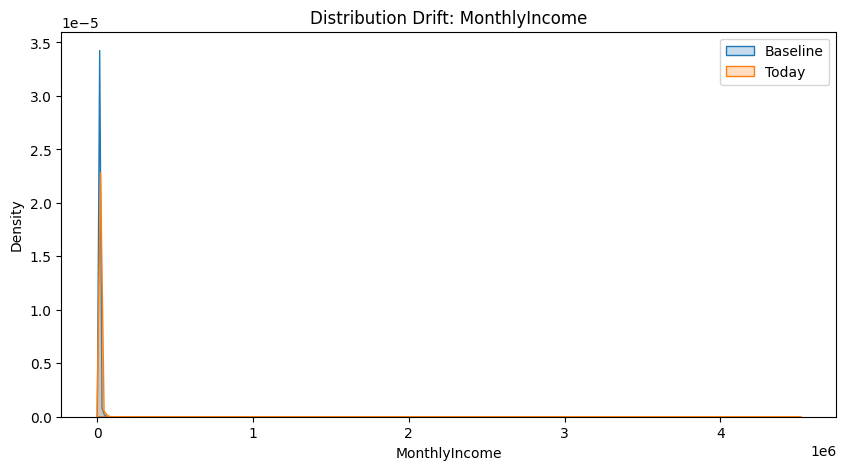

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

col = 'MonthlyIncome'

plt.figure(figsize=(10,5))
sns.kdeplot(df_baseline[col], label='Baseline', fill=True)
sns.kdeplot(df_today[col], label='Today', fill=True)
plt.title(f'Distribution Drift: {col}')
plt.legend()
plt.show()


In [15]:
final_report = quality_df.merge(drift_df, on='feature')
final_report


,feature,missing_spike,range_issue,p_value,drift_detected
0,SeriousDlqin2yrs,True,False,1.000000e+00,False
1,RevolvingUtilizationOfUnsecuredLines,True,False,1.000000e+00,False
2,age,True,True,7.978084e-31,True
3,NumberOfTime30-59DaysPastDueNotWorse,False,False,1.000000e+00,False
4,DebtRatio,False,False,1.000000e+00,False
5,MonthlyIncome,False,True,0.000000e+00,True
6,NumberOfOpenCreditLinesAndLoans,False,False,1.000000e+00,False
7,NumberOfTimes90DaysLate,False,False,1.000000e+00,False
8,NumberRealEstateLoansOrLines,False,False,1.000000e+00,False
9,NumberOfTime60-89DaysPastDueNotWorse,False,False,1.000000e+00,False


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_drift(feature):
    plt.figure(figsize=(10,5))
    sns.kdeplot(df_baseline[feature], label='Baseline', fill=True)
    sns.kdeplot(df_today[feature], label='Today', fill=True)
    plt.title(f'Distribution Drift: {feature}')
    plt.legend()
    plt.show()


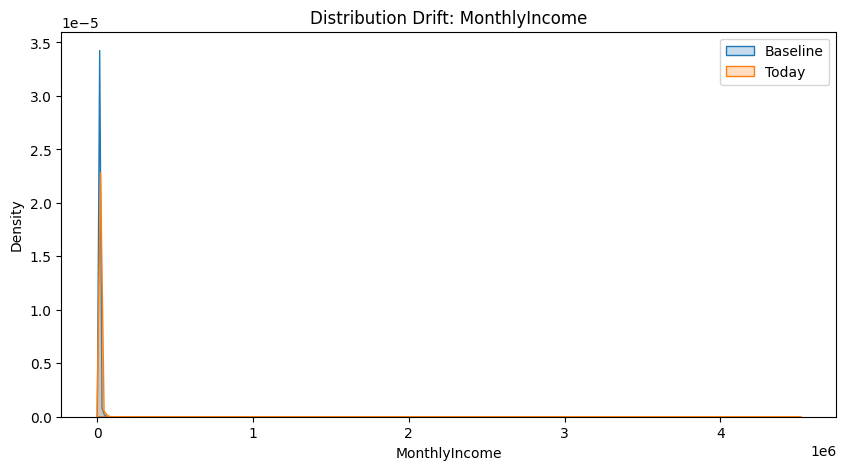

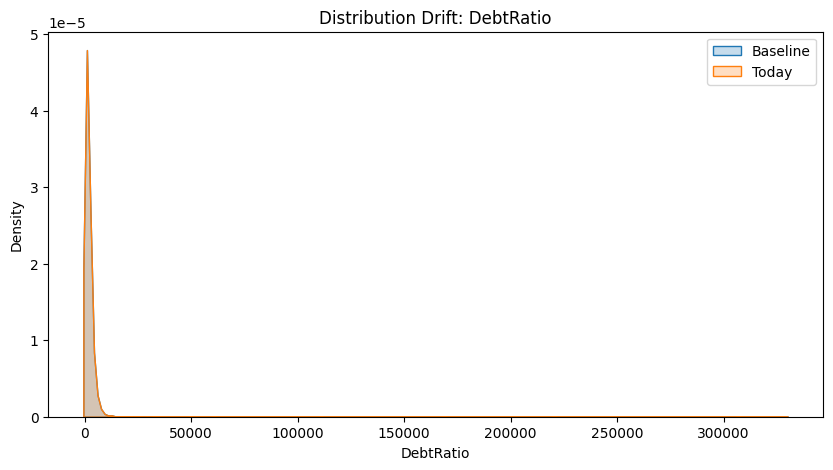

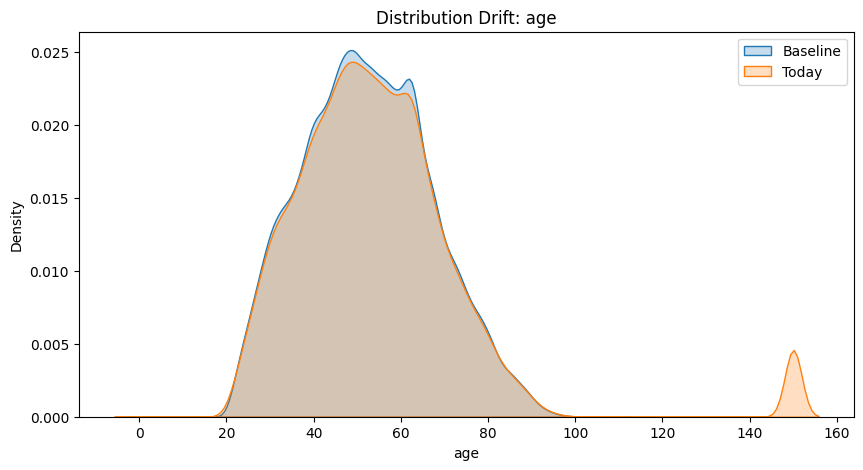

In [18]:
plot_drift('MonthlyIncome')
plot_drift('DebtRatio')
plot_drift('age')


In [19]:
def get_status(row):
    if row['missing_spike'] or row['range_issue'] or row['drift_detected']:
        return "⚠ Issue"
    else:
        return "✅ Stable"

final_report['status'] = final_report.apply(get_status, axis=1)
final_report


,feature,missing_spike,range_issue,p_value,drift_detected,status
0,SeriousDlqin2yrs,True,False,1.000000e+00,False,⚠ Issue
1,RevolvingUtilizationOfUnsecuredLines,True,False,1.000000e+00,False,⚠ Issue
2,age,True,True,7.978084e-31,True,⚠ Issue
3,NumberOfTime30-59DaysPastDueNotWorse,False,False,1.000000e+00,False,✅ Stable
4,DebtRatio,False,False,1.000000e+00,False,✅ Stable
5,MonthlyIncome,False,True,0.000000e+00,True,⚠ Issue
6,NumberOfOpenCreditLinesAndLoans,False,False,1.000000e+00,False,✅ Stable
7,NumberOfTimes90DaysLate,False,False,1.000000e+00,False,✅ Stable
8,NumberRealEstateLoansOrLines,False,False,1.000000e+00,False,✅ Stable
9,NumberOfTime60-89DaysPastDueNotWorse,False,False,1.000000e+00,False,✅ Stable


In [20]:
final_report.to_csv("data_monitoring_report.csv", index=False)


In [21]:
from google.colab import files
files.download("data_monitoring_report.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
def run_monitoring(baseline, today, baseline_profile):
    quality_results = []
    drift_results = []

    from scipy.stats import ks_2samp

    for col in baseline.columns:
        # Quality
        today_missing = today[col].isna().mean()
        baseline_missing = baseline_profile[col]['missing_pct']
        missing_spike = today_missing - baseline_missing > 0.05

        range_issue = (
            today[col].min() < baseline_profile[col]['min'] or
            today[col].max() > baseline_profile[col]['max']
        )

        # Drift
        stat, p_value = ks_2samp(baseline[col].dropna(), today[col].dropna())
        drift_detected = p_value < 0.05

        quality_results.append({
            "feature": col,
            "missing_spike": missing_spike,
            "range_issue": range_issue,
            "drift_detected": drift_detected
        })

    report = pd.DataFrame(quality_results)
    return report

monitoring_output = run_monitoring(df_baseline, df_today, baseline_profile)
monitoring_output


,feature,missing_spike,range_issue,drift_detected
0,SeriousDlqin2yrs,True,False,False
1,RevolvingUtilizationOfUnsecuredLines,True,False,False
2,age,True,True,True
3,NumberOfTime30-59DaysPastDueNotWorse,False,False,False
4,DebtRatio,False,False,False
5,MonthlyIncome,False,True,True
6,NumberOfOpenCreditLinesAndLoans,False,False,False
7,NumberOfTimes90DaysLate,False,False,False
8,NumberRealEstateLoansOrLines,False,False,False
9,NumberOfTime60-89DaysPastDueNotWorse,False,False,False


In [23]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.9 MB/s eta 0:00:00


In [41]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

st.title("📊 Data Drift & Quality Monitoring Dashboard")

# Upload baseline and today data
baseline_file = st.file_uploader("Upload Baseline Data", type=["csv"])
today_file = st.file_uploader("Upload Today's Data", type=["csv"])

if baseline_file and today_file:
    # Drop the Kaggle auto index if present
    df_baseline = pd.read_csv(baseline_file).drop(columns=['Unnamed: 0'], errors='ignore')
    df_today = pd.read_csv(today_file).drop(columns=['Unnamed: 0'], errors='ignore')

    st.subheader("Baseline Data Preview")
    st.write(df_baseline.head())

    st.subheader("Today's Data Preview")
    st.write(df_today.head())


    results = []

    for col in df_baseline.columns:
        if df_baseline[col].dtype != 'object':
            # Missing values
            missing_spike = df_today[col].isna().mean() - df_baseline[col].isna().mean() > 0.05

            # Range check
            range_issue = (
                df_today[col].min() < df_baseline[col].min() or
                df_today[col].max() > df_baseline[col].max()
            )

            # Drift test
            stat, p_value = ks_2samp(df_baseline[col].dropna(), df_today[col].dropna())
            drift_detected = p_value < 0.05

            results.append({
                "feature": col,
                "missing_spike": missing_spike,
                "range_issue": range_issue,
                "drift_detected": drift_detected,
                "p_value": p_value
            })

    report = pd.DataFrame(results)

    st.subheader("Monitoring Report")
    st.dataframe(report)

    # Plot drift for selected feature
    feature = st.selectbox("Select Feature to Visualize Drift", df_baseline.columns)

    fig, ax = plt.subplots()
    sns.kdeplot(df_baseline[feature], label='Baseline', fill=True, ax=ax)
    sns.kdeplot(df_today[feature], label='Today', fill=True, ax=ax)
    ax.set_title(f'Distribution Drift: {feature}')
    ax.legend()
    st.pyplot(fig)


Overwriting app.py


In [42]:
from pyngrok import ngrok


ngrok.set_auth_token("39B9Tag7oMKEHha48qTP9z21VfH_v2hpr5xxhitJyPaQhJd2")
public_url = ngrok.connect(8501)
print(public_url)




NgrokTunnel: "https://unnormal-tined-vicenta.ngrok-free.dev" -> "http://localhost:8501"


In [43]:
!pkill -f streamlit
!streamlit run app.py &



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.198.41.176:8501

  Stopping...


In [37]:
df_today.to_csv("/content/today_data.csv", index=False)


In [38]:
from google.colab import files
files.download("/content/today_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
from google.colab import files
files.download("app.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
files.download("baseline_profile.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>